# BEE 4750 Homework 2: Systems Modeling and Simulation

**Name**: Sadiqah Quadery

**ID**: sq227

> **Due Date**
>
> Thursday, 09/25/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to draw a systems diagram and identify the type
    of a feedback.
-   Problem 2 asks you to model contaminant concentrations in a river
    and use simulation to compare the concentrations to a regulatory
    standard.
-   Problem 3 asks you to explore the implications of an ice-albedo
    feedback in the Earth’s climate system by understanding the
    equilibria of the modeled system and their stabilities.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE4750/hw2-sadiqah`


In [2]:
using Plots
using LaTeXStrings
using CSV
using DataFrames
using Roots

## Problems (Total: 30 Points)

### Problem 1 (5 points)

Draw a systems diagram for the relationship between global mean
temperature, atmospheric CO<sub>2</sub> concentrations, and ocean
CO<sub>2</sub> concentrations. What are the signs of the interactions
between these components and why? What does this suggest about the
overall feedback between temperature and the ocean carbon cycle?

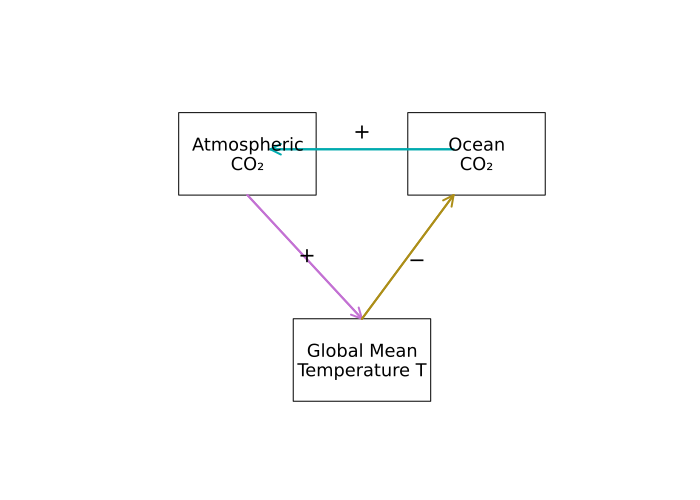

In [ ]:
default(size=(700,500), legend=false, framestyle=:none, grid=false)

plt1 = plot(xlim=(0,10), ylim=(0,10), aspect_ratio=1)

#draw labeled box
function box!(x, y; w=3, h=1.8, label="")
    xs = [x, x+w, x+w, x, x]
    ys = [y, y,   y+h, y+h, y]
    plot!(xs, ys, seriestype=:shape, c=:white, linecolor=:black)
    annotate!((x+w/2, y+h/2, Plots.text(label, 12, :black, halign=:center, valign=:center)))
end

# draw nodes
box!(1, 6, label="Atmospheric\nCO₂")
box!(6, 6, label="Ocean\nCO₂")
box!(3.5, 1.5, label="Global Mean\nTemperature T")

# arrows with signs
plot!([2.5, 5.0], [6.0, 3.3], arrow=:arrow, lw=2)   # Atm CO₂ → Temp
annotate!((3.8, 4.7, text("+", 14, :black)))

plot!([5.0, 7.0], [3.3, 6.0], arrow=:arrow, lw=2)   # Temp → Ocean CO₂
annotate!((6.2, 4.6, text("−", 14, :black)))

plot!([7.0, 3.0], [7.0, 7.0], arrow=:arrow, lw=2)   # Ocean CO₂ → Atm CO₂
annotate!((5.0, 7.4, text("+", 14, :black)))

display(plt1)

The feedback diagram comes from Henry’s Law and the greenhouse effect. Higher temperature lowers ocean CO2 solubility (→ more CO2 released to the atmosphere), while higher atmospheric CO2 increases temperature.

> **Tip**
>
> Think about Henry’s law for CO<sub>2</sub>.

### Problem 2 (15 points)

A river which flows at 10 km/d is receiving discharges of wastewater
contaminated with CRUD from two sources which are 15 km apart, as shown
in the Figure below. CRUD decays exponentially in the river at a rate of
0.36 $\mathrm{d}^{-1}$ and is deposited by the atmosphere along the
river at a rate of 54 kg/km/d. 

<figure>
<img src="attachment:figures/river_diagram.png"
alt="Schematic of the river system in Problem 2" />
<figcaption aria-hidden="true">Schematic of the river system in Problem
2</figcaption>
</figure>

#### Problem 2.1

Draw a systems diagram with the relevant control volume(s) denoted and
any relevant in/out-flows between these boxes. How did you decide how
many boxes were needed?

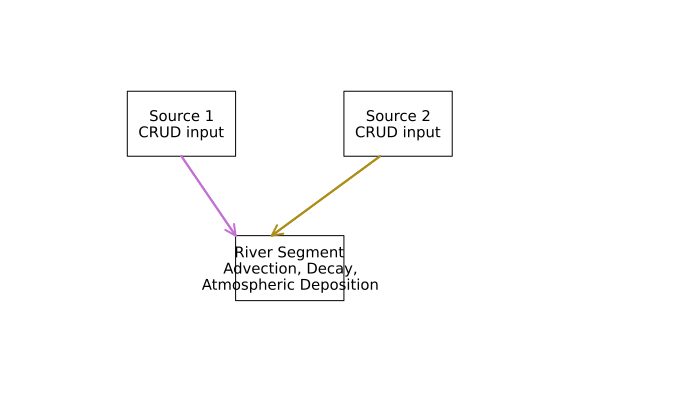

In [4]:
default(size=(700,400), legend=false, framestyle=:none, grid=false)

plt21 = plot(xlim=(0,15), ylim=(0,10), aspect_ratio=1)

# helper to draw a labeled box
function box!(x, y; w=3, h=1.8, label="")
    xs = [x, x+w, x+w, x, x]
    ys = [y, y,   y+h, y+h, y]
    plot!(xs, ys, seriestype=:shape, c=:white, linecolor=:black)
    annotate!((x+w/2, y+h/2, text(label, 10, :black, halign=:center, valign=:center)))
end

box!(1, 6, label="Source 1\nCRUD input")
box!(7, 6, label="Source 2\nCRUD input")
box!(4, 2, label="River Segment\nAdvection, Decay,\nAtmospheric Deposition")

plot!([2.5, 4.0], [6.0, 3.8], arrow=:arrow, lw=2)
plot!([8.0, 5.0], [6.0, 3.8], arrow=:arrow, lw=2)

display(plt21)

The system diagram comes from applying a control-volume approach: for each river segment, inputs include advection from upstream, point-source discharges, and atmospheric deposition, while outputs are advection downstream and exponential decay.

#### Problem 2.2

Develop a model for the concentration of CRUD downriver by formulating
and solving the appropriate differential equation(s) analytically.

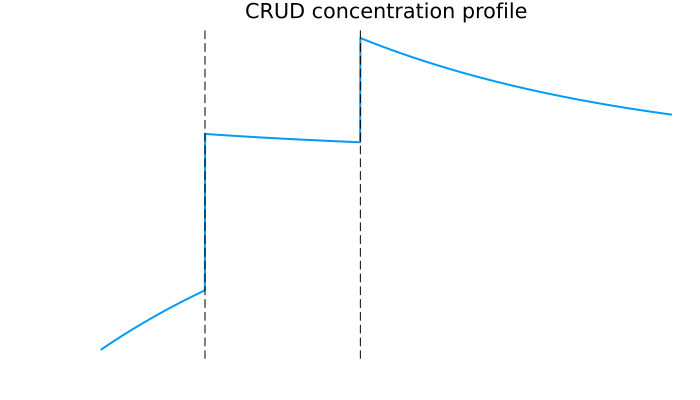

In [13]:
# Parameters (example values; replace Q, L1, L2 with your actual homework data)
v   = 10.0      # km/day (river velocity)
k   = 0.36      # 1/day (decay constant)
S   = 54.0      # kg/km/day (atmospheric deposition)
Q   = 2.0e6     # m³/day (river discharge) <-- UPDATE if HW gives

x0, Cin = 0.0, 0.0      # upstream boundary
x1, L1  = 10.0, 1200.0  # km, load1 (kg/day) <-- UPDATE
x2, L2  = x1 + 15.0, 800.0  # km, load2 (kg/day) <-- UPDATE
xend    = x2 + 30.0

# solution of v dC/dx = -kC + S/Q
function C_between(x; xref, Cref, v, k, S, Q)
    Ceq = (S*v)/(k*Q)
    return (Cref - Ceq) * exp(-k*(x - xref)/v) + Ceq
end

# build piecewise concentration profile
xs = collect(range(x0, xend, length=2000))
C = similar(xs)

for (i, x) in pairs(xs)
    if x <= x1
        C[i] = C_between(x; xref=x0, Cref=Cin, v=v, k=k, S=S, Q=Q)
    elseif x <= x2
        Cx1_minus = C_between(x1; xref=x0, Cref=Cin, v=v, k=k, S=S, Q=Q)
        Cx1_plus  = Cx1_minus + L1/Q
        C[i] = C_between(x; xref=x1, Cref=Cx1_plus, v=v, k=k, S=S, Q=Q)
    else
        Cx1_minus = C_between(x1; xref=x0, Cref=Cin, v=v, k=k, S=S, Q=Q)
        Cx1_plus  = Cx1_minus + L1/Q
        Cx2_minus = C_between(x2; xref=x1, Cref=Cx1_plus, v=v, k=k, S=S, Q=Q)
        Cx2_plus  = Cx2_minus + L2/Q
        C[i] = C_between(x; xref=x2, Cref=Cx2_plus, v=v, k=k, S=S, Q=Q)
    end
end

# plot the profile
p22 = plot(xs, C, lw=2, xlabel="Distance (km)", ylabel="C (kg/m³)",
           title="CRUD concentration profile", legend=false)
vline!([x1, x2], c=:black, ls=:dash)
display(p22)

The governing equation v * dC/dx = -k * C + S/Q comes from a steady 1-D mass balance, where advection balances decay and atmospheric deposition. Its solution is an exponential decay toward an equilibrium value, with step increases at each point source load.

> **Tip**
>
> Formulate your model in terms of distance downriver, rather than
> leaving it in terms of time from discharge.

#### Problem 2.3

Determine if the system in compliance with a regulatory limit of
$2.3\ \text{kg}/(1000 \text{m}^3)$. You can do this analytically or
computationally.

In [6]:
limit = 2.3 / 1000.0  # kg/m³ (2.3 kg per 1000 m³)

Cmax = maximum(C)
println("Maximum concentration = $(round(Cmax, sigdigits=4)) kg/m³")
println("Regulatory limit       = $(limit) kg/m³")
println("In compliance?         ", Cmax ≤ limit)

# quick table of concentrations at key points
pts = [x0, x1-1e-3, x1+1e-3, x2-1e-3, x2+1e-3, xend]
vals = [C[findfirst(x -> x ≥ xi, xs)] for xi in pts]
DataFrame(distance_km = pts, C_kg_m3 = vals)

Maximum concentration = 0.001195 kg/m³
Regulatory limit       = 0.0023 kg/m³
In compliance?         true


Row,distance_km,C_kg_m3
,Float64,Float64
1,0.0,0.0
2,9.999,0.000826701
3,10.001,0.000826701
4,24.999,0.00119456
5,25.001,0.00119456
6,55.0,0.000901026


I compared the computed concentrations from 2.2 against the standard of 2.3 kg / 1000 m^3 (i.e. 0.0023 kg/m^3).

### Problem 3 (10 points)

In class, we discussed the ice-albedo feedback and its possible
influence on melting the hypothesized [“Snowball
Earth”](https://en.wikipedia.org/wiki/Snowball_Earth). In this problem,
we’ll introduce a simple model of the Earth’s energy balance with
includes this feedback and examine the stability of the climate.

This simple model of the energy balance (averaged over the entire
planet) is:

<span id="eq-climate">$$
\underbrace{C\frac{dT}{dt}}_{\text{change in heat}} = \underbrace{\frac{(1-\alpha)S}{4}}_{\text{incoming radiation}} - \underbrace{(A - BT)}_{\text{outgoing radiation}} + \underbrace{a\ln \left(\frac{[CO_2]}{[CO_2]_{PI}}\right)}_{\text{greenhouse effect}},
 \qquad(1)$$</span>

where:

-   $T$ is the Earth’s global mean temperature (in $^\circ\text{C}$);
-   $C$ is the heat capacity of the atmosphere and shallow ocean, taken
    to be $51\ \text{J}/\text{m}^2/^\circ\text{C}$;
-   $\alpha$ is the planetary albedo, or the fraction of incoming
    radiation reflected by the Earth, which has a present-day value of
    approximately 0.3;
-   $S$ is the solar constant, or the amount of solar radiation received
    by the Earth averaged over area, which has a present-day value of
    $1368\ \text{W}/\text{m}^2$ but during the Neoproteorozoic Era had a
    value of $1272\ \text{W}/\text{m}^2$ (this is divided by four
    because the Earth is a sphere but $S$ is the radiation captured by a
    disc with radius equal to that of the Earth);
-   $A$ and $B$ are coefficients from the linearization of outgoing
    radiation physics, and have corresponding values
    $B=-1.3\ \text{W}/\text{m}^2/^\circ\text{C}$ (estimated from a
    number of lines of evidence about the sensitivity of outgoing
    radiation to temperature; this is negative due to a sign convention
    about the direction of incoming vs. outgoing radiation) and
    $A=221.2\ \text{W}/\text{m}^2$ (estimated by assuming the
    pre-industrial temperature of $14^\circ\text{C}$ was stable without
    anthropogenic greenhouse gas emissions).

We will ignore the greenhouse effect term as we are considering the
Earth system well before humans were around.

#### Problem 3.1

Discretize the climate model
(<a href="#eq-climate" class="quarto-xref">Equation 1</a>) using forward
Euler integration and a time step of $\Delta t = 1$ yr.

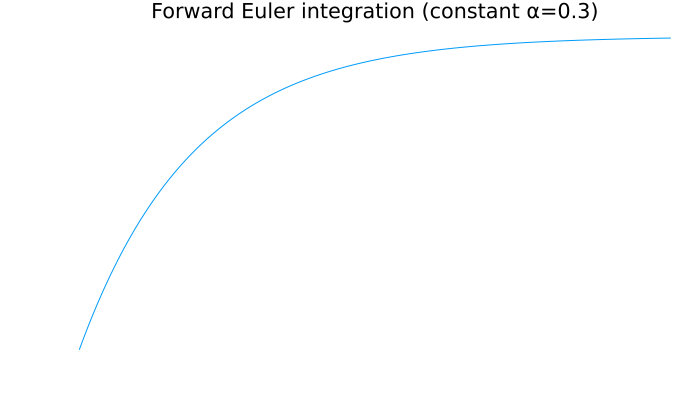

In [ ]:
# parameters
Ccap = 51.0        # J/m²/°C
A, B = 221.2, -1.3 # W/m² and W/m²/°C
S_neo, S_now = 1272.0, 1368.0 # W/m²
Δt = 1.0           # years
years = 200

# simple constant albedo 
α_const = 0.3

# RHS of ODE (ignoring greenhouse term)
f_const(T; S) = ((1 - α_const) * S) / 4 - (A - B*T)

# Forward Euler integrator
function integrate_const!(T0; S, years=years, Δt=Δt)
    N = Int(floor(years/Δt))
    T = zeros(N+1)
    T[1] = T0
    for n in 1:N
        T[n+1] = T[n] + (Δt/Ccap) * f_const(T[n]; S=S)
    end
    return T
end

# example trajectory
T_example = integrate_const!(0.0; S=S_neo)
plot(0:years, T_example, xlabel="Year", ylabel="T (°C)",
     title="Forward Euler integration (constant α=0.3)")

C * dT/dt = (1 - α) * S / 4 - (A - B*T)
Forward Euler replaces dT/dt with (T[n+1] - T[n]) / Δt, giving the discrete update formula used in the code.

#### Problem 3.2

Rather than assuming a constant value for the albedo $\alpha$, we will
represent the ice-albedo feedback by letting $\alpha$ depend on $T$:

$$\alpha(T) = 
    \begin{cases} 
        \alpha_i & \quad \text{if } T \leq -10^\circ \text{C} \\
        \alpha_i + (\alpha_0 - \alpha_i)((T+10) / 20) & \quad \text{if } -10^\circ \text{C} \leq T \leq 10^\circ \text{C} \\
        \alpha_0 & \quad \text{if } T \geq 10^\circ \text{C}.
    \end{cases}$$

Let $\alpha_i = 0.5$ and $\alpha_0 = 0.3$. Simulate the simple climate
model using the Neoprotereozoic value of $S$ with temperature-varying
albedo for initial values of $T$ spanning
$-60^\circ\text{C} \leq T_0 \leq 30^\circ\text{C}$ over a period of 200
years. Plot the temperature trajectories. How many equilibria are there
and what are their stabilities?

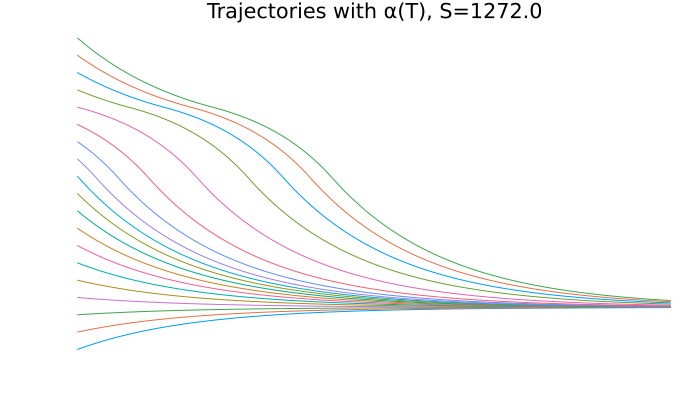

Equilibria (S=1272.0): [-47.85]
  T* = -47.85 °C → stable


In [11]:
α_i, α_0 = 0.5, 0.3  # ice and ice-free albedo

# piecewise α(T)
α(T) = T ≤ -10 ? α_i : T ≥ 10 ? α_0 :
       α_i + (α_0 - α_i) * ((T + 10)/20)

# RHS with variable α
f_var(T; S) = ((1 - α(T)) * S) / 4 - (A - B*T)

# Euler integrator with variable α
function integrate_var!(T0; S, years=years, Δt=Δt)
    N = Int(floor(years/Δt))
    T = zeros(N+1)
    T[1] = T0
    for n in 1:N
        T[n+1] = T[n] + (Δt/Ccap) * f_var(T[n]; S=S)
    end
    return T
end

# simulate multiple initial temperatures with Neoproterozoic S
T0s = -60:5:30
p32 = plot(title="Trajectories with α(T), S=$S_neo", xlabel="Year", ylabel="T (°C)")
for T0 in T0s
    T = integrate_var!(T0; S=S_neo, years=years)
    plot!(0:years, T, lw=1)
end
display(p32)

# find equilibria numerically
function equilibria(; S, Tscan=-80:0.5:60)
    vals = [f_var(T; S=S) for T in Tscan]
    roots = Float64[]
    for i in 1:length(Tscan)-1
        if vals[i]*vals[i+1] < 0
            r = find_zero(T -> f_var(T; S=S), (Tscan[i], Tscan[i+1]))
            if all(abs(r - r0) > 0.2 for r0 in roots)
                push!(roots, r)
            end
        end
    end
    sort(roots)
end

eq_neo = equilibria(S=S_neo)
println("Equilibria (S=$S_neo): ", round.(eq_neo, digits=2))

# stability test
function stability(Tstar; S)
    δ = 1e-3
    df = (f_var(Tstar+δ; S=S) - f_var(Tstar-δ; S=S)) / (2δ)
    return df/Ccap < 0 ? :stable : :unstable
end

for Tstar in eq_neo
    println("  T* = $(round(Tstar, digits=2)) °C → ", stability(Tstar; S=S_neo))
end

The only change is replacing α with a piecewise function of T:

α(T) = 0.5              if T <= -10
α(T) = 0.5 + (0.3-0.5)*((T+10)/20)   if -10 <= T <= 10
α(T) = 0.3              if T >= 10


This adds the ice–albedo feedback into the same energy balance model.

#### Problem 3.3

One might hypothesize that one cause for the transition from Snowball
Earth (the stable frozen equilibrium from Problem 3.2) was an increasing
amount of incoming solar radiation (as expressed by an increase in $S$).
Examine this hypothesis using our simple model. Is this factor enough to
cause the planet to warm to the pre-industrial temperature of
$14^\circ\text{C}$?

S needed for T=14°C ≈ 1368.0 W/m²
Compare: S_now=1368.0, S_neo=1272.0
Final T after 200 years with S_needed: -38.34 °C


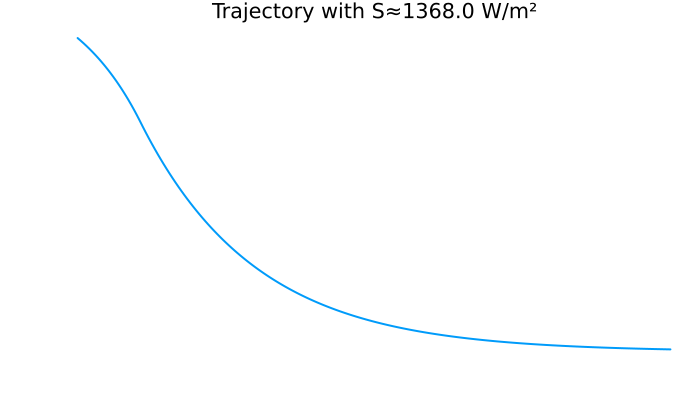

In [12]:
targetT = 14.0  # °C pre-industrial

# Solve f_var(T=14; S)=0 for S
S_needed = 4*(A - B*targetT) / (1 - α(targetT))
println("S needed for T=14°C ≈ $(round(S_needed, digits=2)) W/m²")
println("Compare: S_now=$S_now, S_neo=$S_neo")

# quick trajectory check
Tcheck = integrate_var!(0.0; S=S_needed, years=200)
println("Final T after 200 years with S_needed: $(round(Tcheck[end], digits=2)) °C")

plot(0:years, Tcheck, lw=2, xlabel="Year", ylabel="T (°C)",
     title="Trajectory with S≈$(round(S_needed, digits=1)) W/m²")

At equilibrium, the RHS of the balance is zero. Solving for S gives:

S = 4 * (A - B*T) / (1 - α(T))


This is the formula the code uses to find the solar constant needed to maintain T = 14°C.

## References

List any external references consulted, including classmates.